In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import pyplot as plt
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
from sklearn.model_selection import train_test_split

class DataExplorer:
    def __init__(self, df, sample_size=None):
        if sample_size:
            self.df = df.sample(n=sample_size, random_state=42)
            print(f"Using a sample of {sample_size} rows for exploration.")
        else:
            self.df = df

    # Basic information
    def overview(self):
        print("Dataset Overview")
        print(f"Shape: {self.df.shape}")
        print(f"\nColumns & Types:")
        print(self.df.dtypes)
        print("\nFirst 10 rows:")
        print(self.df.head(10))

    # Missing values
    def missing_values(self):
        print("Missing Values")
        missing = self.df.isnull().sum()
        print(missing[missing > 0])

    # Descriptive statistics
    def descript_stats(self):
        print("Descriptive Statistics")
        print(self.df.describe())

    # Histograms
    def plot_histograms(self):
        numeric = self.df.select_dtypes(include=['int64', 'float64'])
        if numeric.empty:
            print("No numeric columns to plot histograms.")
            return
        numeric.hist(bins=30, figsize=(12, 8))
        plt.tight_layout()
        plt.show()

    # BoxPlots
    def plot_boxplot(self):
        numeric = self.df.select_dtypes(include=['int64', 'float64'])
        for col in numeric.columns:
            plt.figure(figsize=(8, 4))
            sns.boxplot(x=self.df[col])
            plt.title(f'Boxplot of {col}')
            plt.show()

    # Correlation matrix
    def correlation_matrix(self):
        numeric = self.df.select_dtypes(include=['int64', 'float64'])
        if numeric.empty:
            print("No numeric columns for correlation.")
            return
        corr = numeric.corr()
        print("\n=== Correlation Matrix ===")
        print(corr)
        plt.figure(figsize=(10, 8))
        sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
        plt.show()

    # Linear regression example
    def linear_regression(self, x_col, y_col):
        if x_col not in self.df.columns or y_col not in self.df.columns:
            print(f"Columns {x_col} or {y_col} not found.")
            return
        X = self.df[[x_col]].values.reshape(-1, 1)
        y = self.df[y_col].values
        model = LinearRegression()
        model.fit(X, y)
        y_pred = model.predict(X)

        plt.figure(figsize=(10, 6))
        plt.scatter(X, y, color='blue', label='Actual')
        plt.plot(X, y_pred, color='red', label='Regression')
        plt.xlabel(x_col)
        plt.ylabel(y_col)
        plt.title(f'Linear Regression: {x_col} vs {y_col}')
        plt.legend()
        plt.show()

        print(f"\nCoefficient: {model.coef_[0]:.4f}, Intercept: {model.intercept_:.4f}")

    # Pivot table - total items per user/product
    def pivot_table_summary(self, index_col,values_col='product_id', aggfunc='count'):
        if index_col not in self.df.columns:
            print(f"Columns {index_col} not found in dataframe.")
            return None
        pivot = pd.pivot_table(
            self.df,
            index=index_col,
            values=values_col,
            aggfunc=aggfunc,
        ).sort_values(by=values_col, ascending=False)
        print(f"\nPivot Table: {aggfunc} of {values_col} by {index_col}")
        print(pivot.head(50))
        return pivot

    # Reorder probability per product
    def reorder_probability(self):
        if 'reordered' not in self.df.columns or 'product_id' not in self.df.columns:
            print("Required columns not found for reorder probability.")
            return
        prob = self.df.groupby('product_id')['reordered'].mean().sort_values(ascending=False)
        print("\nTop 10 Products by Reorder Probability:")
        print(prob.head(10))

        # Plot top 20
        plt.figure(figsize=(12, 6))
        prob.head(20).plot(kind='bar', color='skyblue')
        plt.ylabel("Reorder Probability")
        plt.xlabel("Product ID")
        plt.title("Top 20 Products by Reorder Probability")
        plt.show()

        return prob

    def predict_reorder(self, feature_cols=None):
        if 'reordered' not in self.df.columns:
            print("Column 'reordered' not found.")
            return

        # Default features if none provided
        if feature_cols is None:
            feature_cols = ['total_items_in_order', 'total_orders_by_user', 'add_to_cart_order']

        # Drop rows with missing features
        df_model = self.df.dropna(subset=feature_cols + ['reordered'])

        X = df_model[feature_cols]
        y = df_model['reordered']

        # Train-test split
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

        # Logistic regression model
        model = LogisticRegression(max_iter=1000)
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:, 1]

        # Metrics
        print("\nClassification Report")
        print(classification_report(y_test, y_pred))
        print("ROC AUC:", roc_auc_score(y_test, y_prob))

        # Optional confusion matrix heatmap
        cm = confusion_matrix(y_test, y_pred)
        plt.figure(figsize=(6, 4))
        sns.heatmap(cm, annot=True, fmt="d", cmap='Blues')
        plt.xlabel("Predicted")
        plt.ylabel("Actual")
        plt.title("Confusion Matrix")
        plt.show()

Using a sample of 100000 rows for exploration.
Dataset Overview
Shape: (100000, 17)

Columns & Types:
order_id                    int64
product_id                  int64
add_to_cart_order           int64
reordered                   int64
product_name                  str
aisle_id                    int64
department_id               int64
aisle                         str
department                    str
user_id                     int64
eval_set                      str
order_number                int64
order_dow                   int64
order_hour_of_day           int64
days_since_prior_order    float64
total_items_in_order        int64
total_orders_by_user        int64
dtype: object

First 10 rows:
          order_id  product_id  add_to_cart_order  reordered  \
7009614     740068       21616                 16          0   
12886293   1360271       35503                  5          1   
30444410   3211401        5819                 13          1   
27795025   2931112        9387    

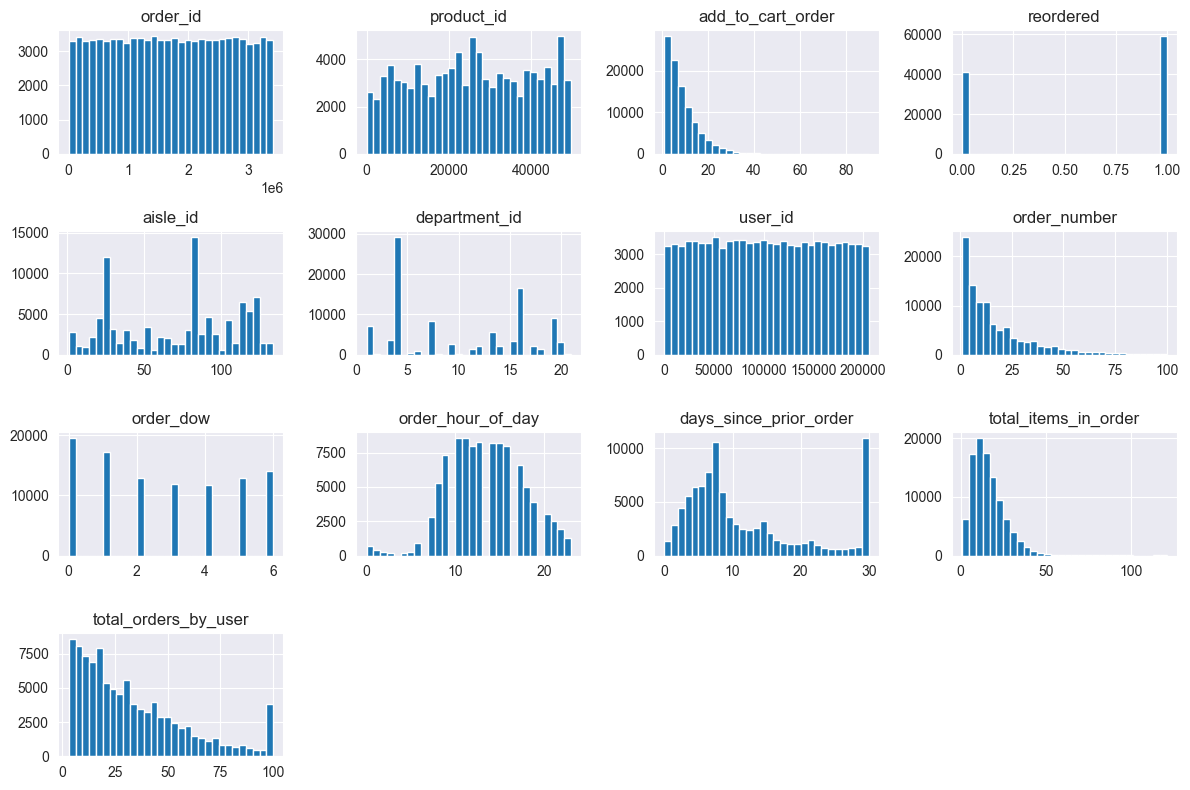

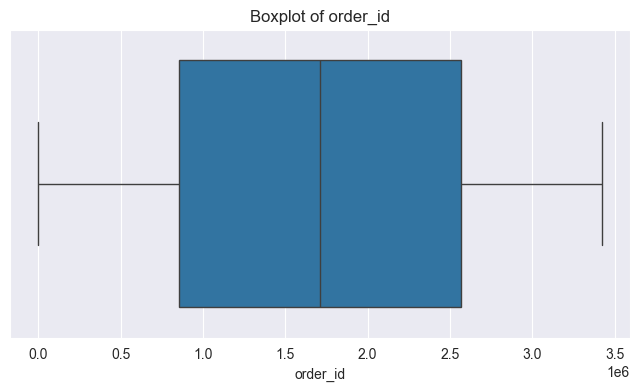

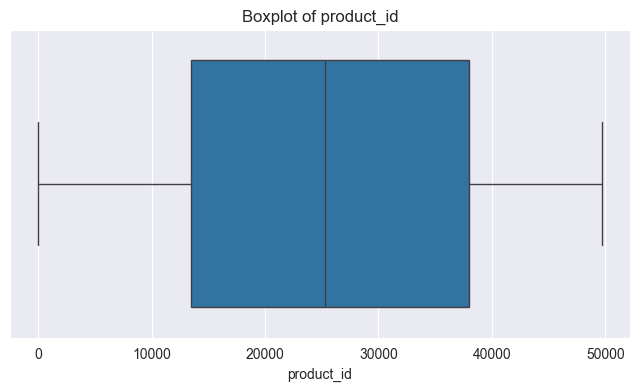

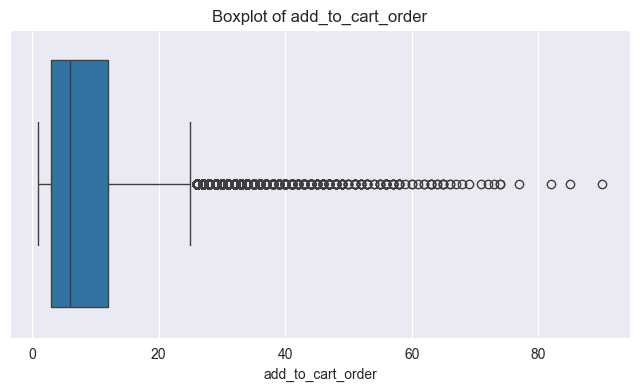

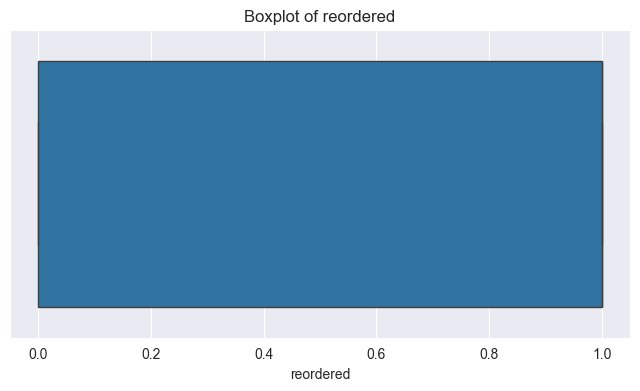

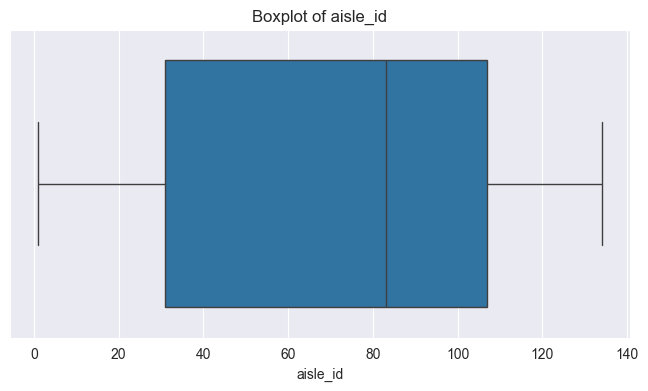

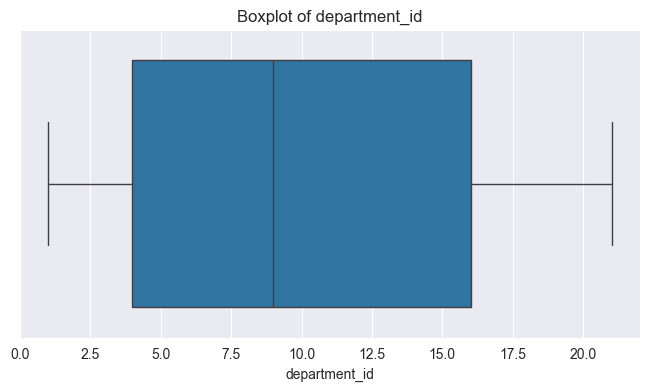

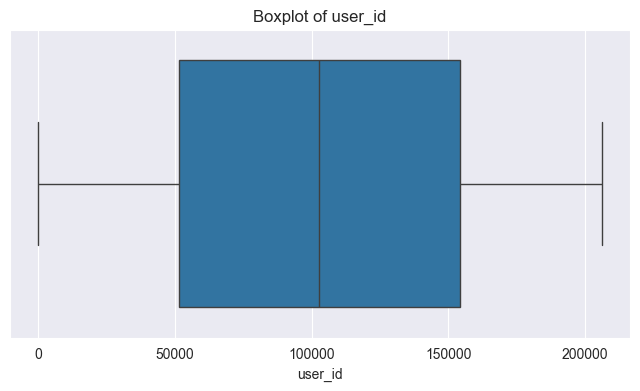

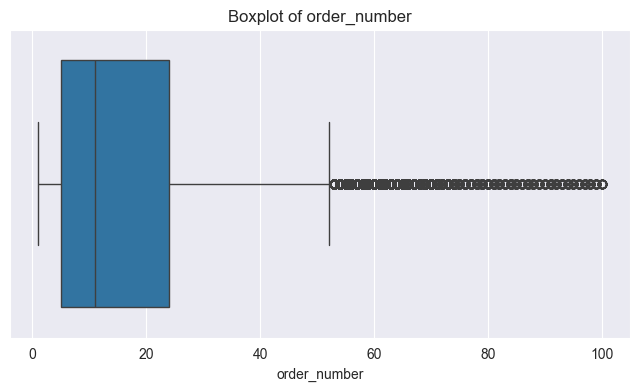

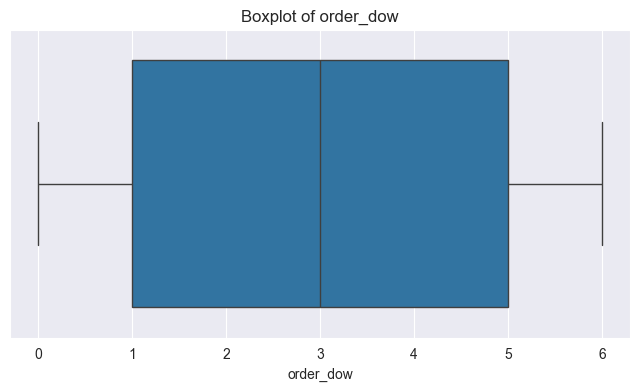

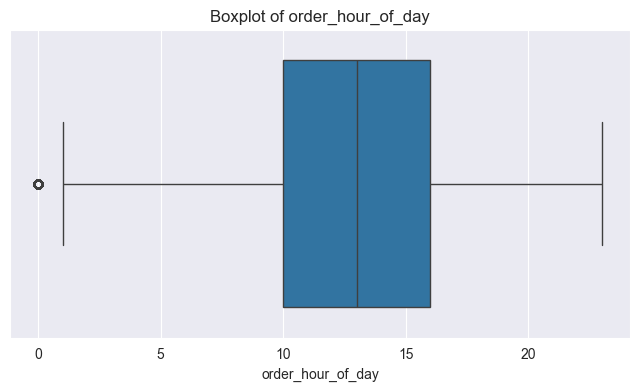

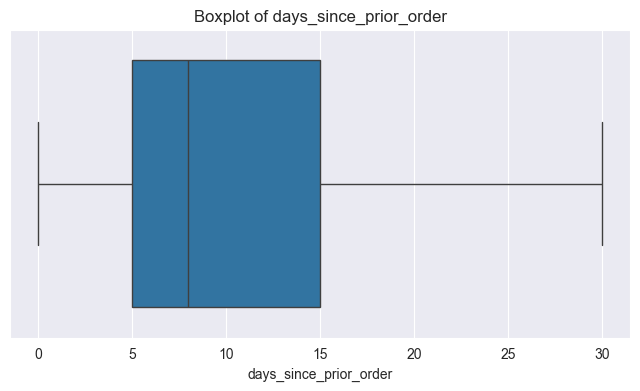

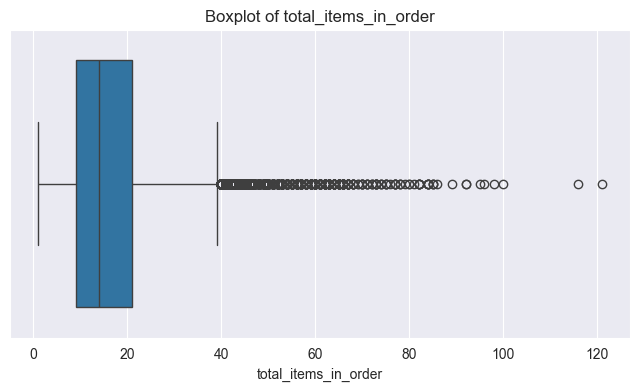

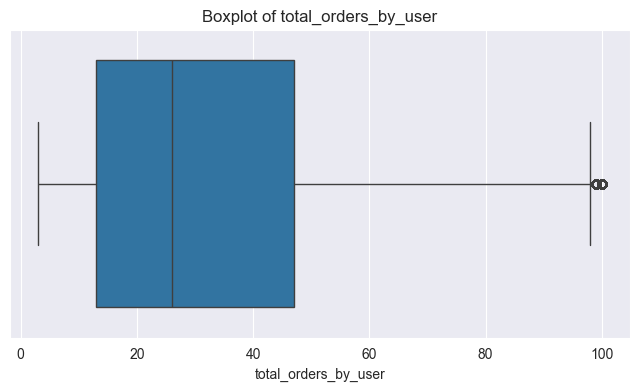


=== Correlation Matrix ===
                        order_id  product_id  add_to_cart_order  reordered  \
order_id                1.000000   -0.006718          -0.003109   0.001327   
product_id             -0.006718    1.000000           0.001654   0.007158   
add_to_cart_order      -0.003109    0.001654           1.000000  -0.136844   
reordered               0.001327    0.007158          -0.136844   1.000000   
aisle_id               -0.003081    0.007609           0.008059   0.004757   
department_id          -0.008524   -0.025442           0.031494  -0.040097   
user_id                -0.002079    0.000856          -0.003883   0.001036   
order_number           -0.001622   -0.002419          -0.001203   0.299219   
order_dow               0.001077   -0.007656          -0.010681  -0.010744   
order_hour_of_day       0.005164    0.003174          -0.015139  -0.025270   
days_since_prior_order -0.001563    0.003016           0.052617  -0.133788   
total_items_in_order   -0.000370    

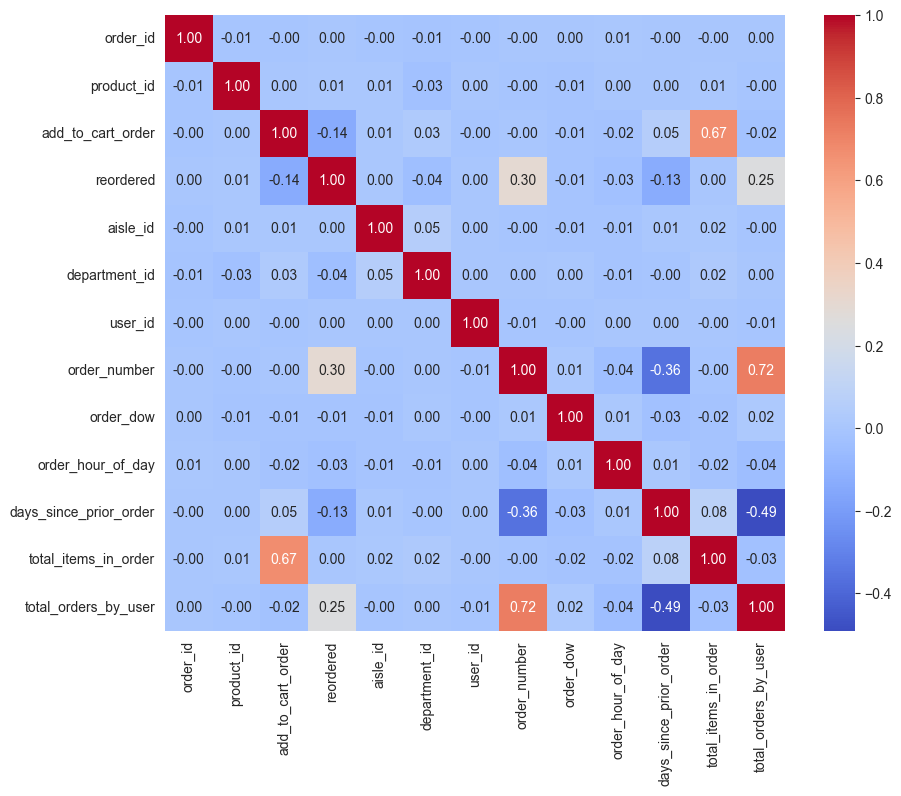


Pivot Table: count of product_id by user_id
         product_id
user_id            
201268           14
186704           13
175540           13
33731            12
202035           12
144750           12
23371            12
147538           11
30737            11
190736           11
23832            11
44330            11
5360             10
1424             10
78686            10
52008            10
4694             10
4625             10
21782            10
192287           10
12853            10
108031           10
175627           10
193056           10
172806            9
203318            9
176478            9
150840            9
143402            9
105939            9
68713             9
41108             9
72934             9
28685             9
82516             9
82085             9
108736            9
57546             9
152551            9
159591            9
89079             9
189425            9
154508            9
100330            9
99608             9
26645          

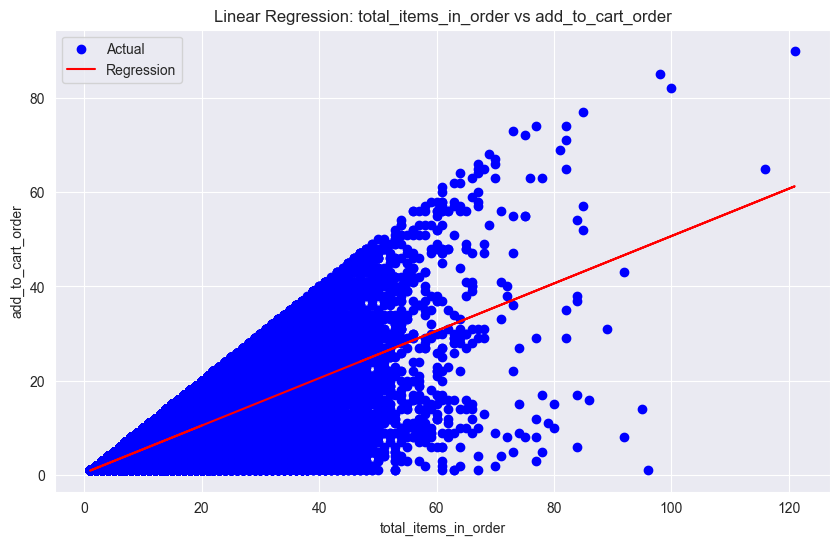


Coefficient: 0.5021, Intercept: 0.4693

Classification Report
              precision    recall  f1-score   support

           0       0.61      0.47      0.53      8172
           1       0.68      0.80      0.74     11828

    accuracy                           0.66     20000
   macro avg       0.65      0.63      0.63     20000
weighted avg       0.65      0.66      0.65     20000

ROC AUC: 0.6875271781817736


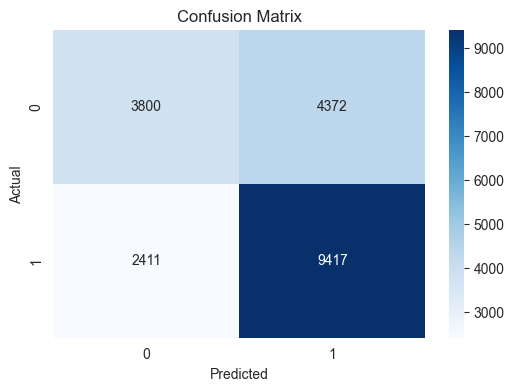

In [10]:
if __name__ == "__main__":
    # Load clean data
    df = pd.read_csv("../data/clean/clean_data.csv")

    explorer = DataExplorer(df, sample_size=100000)

    explorer.overview()
    explorer.missing_values()
    explorer.descript_stats()
    explorer.plot_histograms()
    explorer.plot_boxplot()
    explorer.correlation_matrix()

    pivot_user = explorer.pivot_table_summary('user_id')
    pivot_product = explorer.pivot_table_summary('product_name')

    # Linear Regression: 'total_items_in_order' vs 'add_to_cart_order'
    explorer.linear_regression('total_items_in_order', 'add_to_cart_order')

    # Logistic regression
    explorer.predict_reorder()